In [ ]:
#!pip install kagglehub torchcam scikit-learn seaborn

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchvision import transforms
from torchvision.models import resnet50, ResNet50_Weights

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
import kagglehub

path = kagglehub.dataset_download("andrewmvd/leukemia-classification")

data_dir = os.path.join(path, "C-NMC_Leukemia", "training_data", "fold_0")

Using Colab cache for faster access to the 'leukemia-classification' dataset.


In [ ]:
class LeukemiaDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))

        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_path):
                continue

            for img in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
def get_transforms():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(25),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

In [ ]:
dataset = LeukemiaDataset(data_dir, transform=get_transforms())

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

In [ ]:
labels = dataset.labels

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

weights = torch.tensor(weights, dtype=torch.float).to(device)

In [ ]:
class Model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base = resnet50(weights=ResNet50_Weights.DEFAULT)

        self.features = nn.Sequential(*list(base.children())[:-1])

        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [ ]:
num_classes = len(dataset.classes)

model = Model(num_classes).to(device)

# Freeze backbone first
for param in model.features.parameters():
    param.requires_grad = False

optimizer = optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss(weight=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 83.4MB/s]


In [ ]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader):
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            pred = torch.argmax(outputs, dim=1).cpu().numpy()

            preds.extend(pred)
            targets.extend(labels.numpy())

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average='macro')

    return acc, f1, preds, targets

In [ ]:
for epoch in range(5):
    loss = train_epoch(model, train_loader)
    acc, f1, _, _ = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}, F1={f1:.4f}")

Epoch 1: Loss=0.5773, Acc=0.7436, F1=0.7296
Epoch 2: Loss=0.4814, Acc=0.8286, F1=0.7803
Epoch 3: Loss=0.4754, Acc=0.8513, F1=0.8182
Epoch 4: Loss=0.4515, Acc=0.8116, F1=0.7807
Epoch 5: Loss=0.4509, Acc=0.8470, F1=0.8247


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-5)

for epoch in range(5):
    loss = train_epoch(model, train_loader)
    acc, f1, _, _ = evaluate(model, val_loader)

    print(f"[FT] Epoch {epoch+1}: Loss={loss:.4f}, Acc={acc:.4f}, F1={f1:.4f}")

[FT] Epoch 1: Loss=0.4257, Acc=0.8626, F1=0.8389
[FT] Epoch 2: Loss=0.4017, Acc=0.8881, F1=0.8701
[FT] Epoch 3: Loss=0.3660, Acc=0.8626, F1=0.8474
[FT] Epoch 4: Loss=0.3355, Acc=0.8725, F1=0.8542
[FT] Epoch 5: Loss=0.3033, Acc=0.8442, F1=0.8297


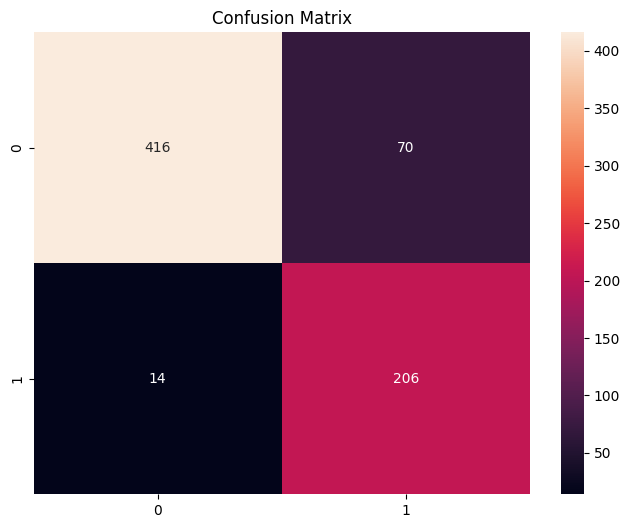

In [ ]:
acc, f1, preds, targets = evaluate(model, val_loader)

cm = confusion_matrix(targets, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
cam_extractor = GradCAM(model, target_layer='features.7')

In [ ]:
def show_gradcam(model, dataset, idx=0):
    model.eval()

    img, label = dataset[idx]
    input_tensor = img.unsqueeze(0).to(device)

    output = model(input_tensor)
    pred_class = output.argmax().item()

    activation_map = cam_extractor(pred_class, output)

    img_np = img.permute(1,2,0).cpu().numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    heatmap = activation_map[0].squeeze().cpu().numpy()

    plt.imshow(img_np)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)
    plt.title(f"True: {label}, Pred: {pred_class}")
    plt.axis('off')
    plt.show()

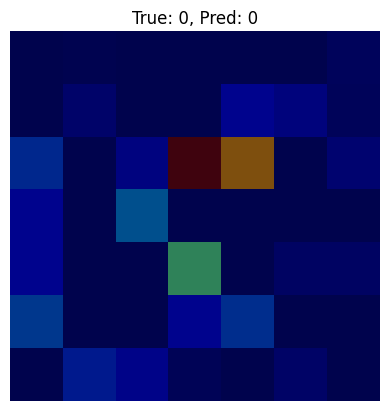

In [ ]:
show_gradcam(model, dataset, idx=10)